# EDA — BGL Supercomputer Logs

Dataset: Blue Gene/L (Loghub) — 4.7M eventos de un supercomputador IBM.

**Objetivos:**
- Entender la estructura y distribución de los logs
- Cuantificar el class imbalance (normal vs anomalía)
- Identificar patrones temporales y por nodo
- Definir la estrategia de features

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

from src.data.loader import load_bgl_logs
from src.data.preprocessor import add_severity_score

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

DATA_PATH = Path('../data/raw/BGL.log')
N_ROWS = 500_000

## 1. Carga de datos

In [2]:
df = load_bgl_logs(DATA_PATH, nrows=N_ROWS)
df = add_severity_score(df)

print(f'Shape: {df.shape}')
print(f'Rango temporal: {df["timestamp"].min()} → {df["timestamp"].max()}')
print()
print(df.dtypes)

Shape: (500000, 11)
Rango temporal: 2005-06-03 15:42:50.363779 → 2005-06-14 09:53:21.296372

label                        str
timestamp_int              int64
date                         str
node                    category
type                    category
component               category
level                   category
content                      str
is_anomaly                  bool
timestamp         datetime64[us]
severity_score              int8
dtype: object


In [3]:
df.head(5)

,label,timestamp_int,date,node,type,component,level,content,is_anomaly,timestamp,severity_score
0,-,1117838570,2005.06.03,R02-M1-N0-C:J12-U11,RAS,KERNEL,INFO,instruction cache parity error corrected,False,2005-06-03 15:42:50.363779,0
1,-,1117838570,2005.06.03,R02-M1-N0-C:J12-U11,RAS,KERNEL,INFO,instruction cache parity error corrected,False,2005-06-03 15:42:50.527847,0
2,-,1117838570,2005.06.03,R02-M1-N0-C:J12-U11,RAS,KERNEL,INFO,instruction cache parity error corrected,False,2005-06-03 15:42:50.675872,0
3,-,1117838570,2005.06.03,R02-M1-N0-C:J12-U11,RAS,KERNEL,INFO,instruction cache parity error corrected,False,2005-06-03 15:42:50.823719,0
4,-,1117838570,2005.06.03,R02-M1-N0-C:J12-U11,RAS,KERNEL,INFO,instruction cache parity error corrected,False,2005-06-03 15:42:50.982731,0


## 2. Class Imbalance

Normal:    293,153 (58.6%)
Anomalía:  206,847 (41.4%)
Ratio anomalía/normal: 1:1


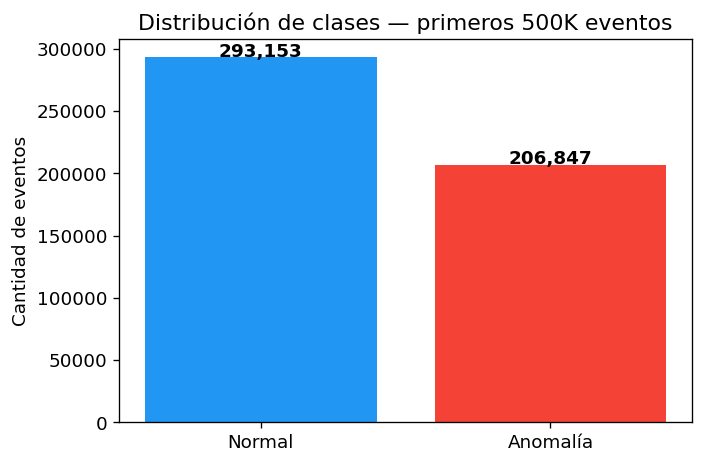

In [4]:
counts = df['is_anomaly'].value_counts()
n_normal = counts[False]
n_anomaly = counts[True]
ratio = n_anomaly / len(df)

print(f'Normal:   {n_normal:>8,} ({1-ratio:.1%})')
print(f'Anomalía: {n_anomaly:>8,} ({ratio:.1%})')
print(f'Ratio anomalía/normal: 1:{int(n_normal/n_anomaly)}')

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['Normal', 'Anomalía'], [n_normal, n_anomaly], color=['#2196F3', '#F44336'])
ax.set_ylabel('Cantidad de eventos')
ax.set_title('Distribución de clases — primeros 500K eventos')
for i, v in enumerate([n_normal, n_anomaly]):
    ax.text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/01_class_distribution.png', dpi=150)
plt.show()

## 3. Distribución por nivel de severidad

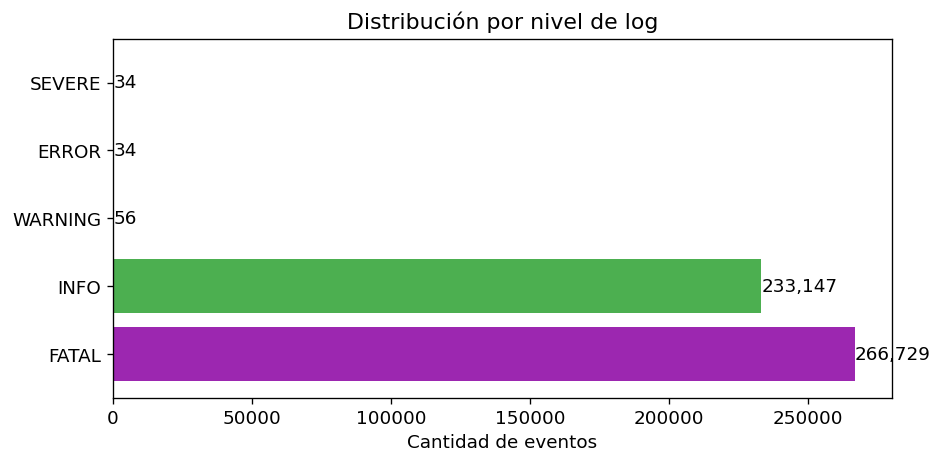

In [5]:
level_counts = df['level'].value_counts()

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#4CAF50' if l == 'INFO' else '#FF9800' if l in ('WARNING','WARN') 
          else '#F44336' if l == 'ERROR' else '#9C27B0' 
          for l in level_counts.index]
ax.barh(level_counts.index.astype(str), level_counts.values, color=colors)
ax.set_xlabel('Cantidad de eventos')
ax.set_title('Distribución por nivel de log')
for i, v in enumerate(level_counts.values):
    ax.text(v + 100, i, f'{v:,}', va='center')
plt.tight_layout()
plt.savefig('../reports/figures/01_level_distribution.png', dpi=150)
plt.show()

## 4. Serie temporal — eventos normales vs anomalías

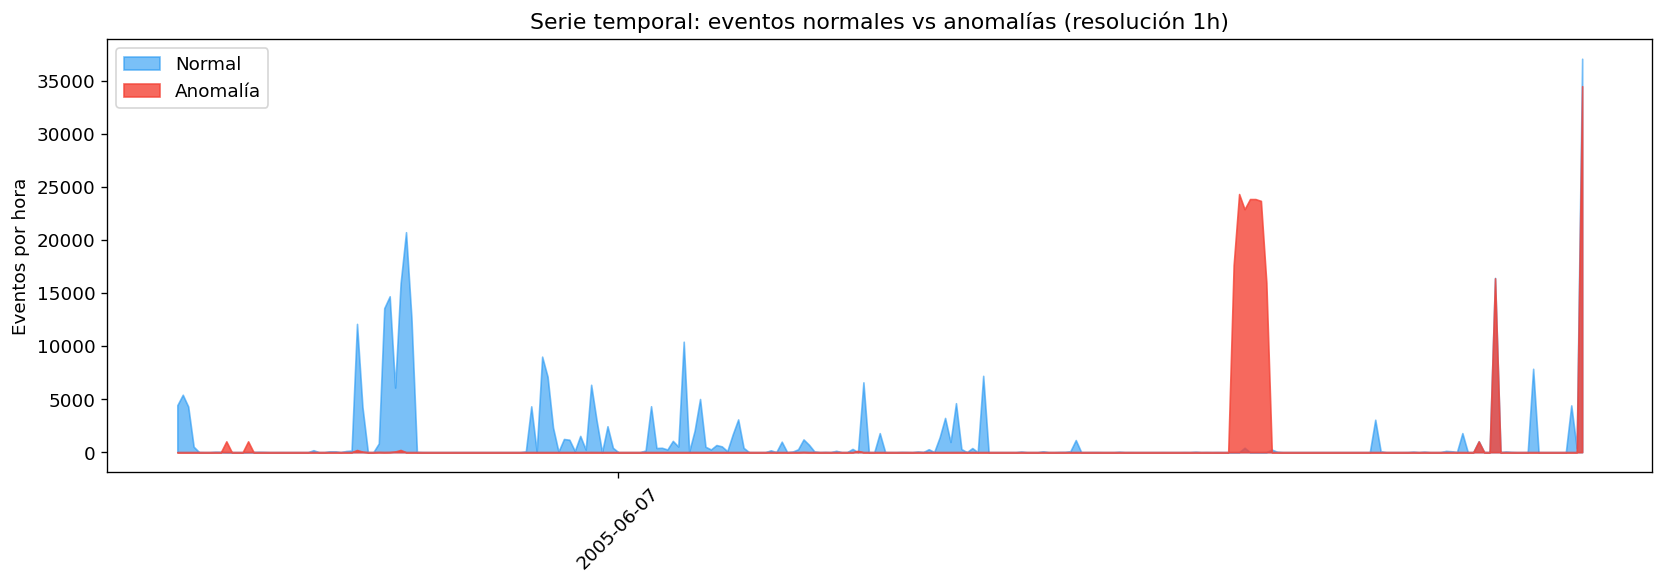

In [6]:
df_ts = df.set_index('timestamp').resample('1h')['is_anomaly'].agg(['sum', 'count'])
df_ts.columns = ['anomalias', 'total']
df_ts['normales'] = df_ts['total'] - df_ts['anomalias']

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(df_ts.index, df_ts['normales'], alpha=0.6, color='#2196F3', label='Normal')
ax.fill_between(df_ts.index, df_ts['anomalias'], alpha=0.8, color='#F44336', label='Anomalía')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.xticks(rotation=45)
ax.set_ylabel('Eventos por hora')
ax.set_title('Serie temporal: eventos normales vs anomalías (resolución 1h)')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/01_timeseries.png', dpi=150)
plt.show()

## 5. Top nodos con más anomalías

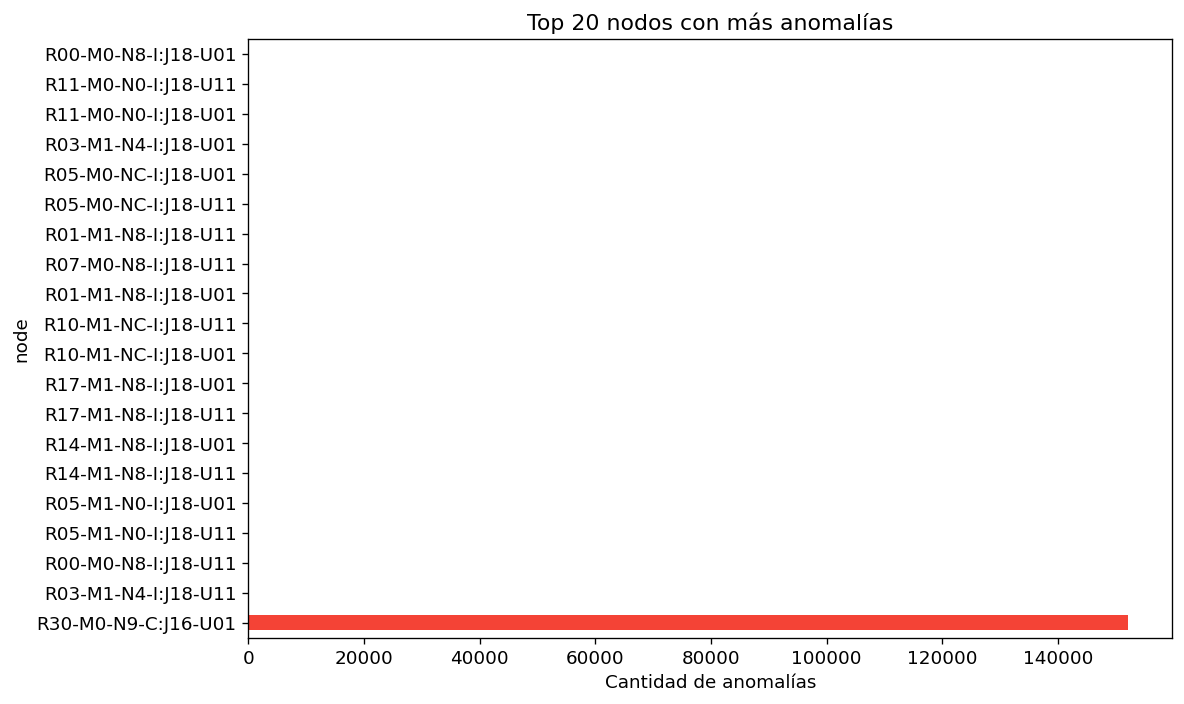

Top 5 nodos con anomalías:
node
R30-M0-N9-C:J16-U01    152185
R03-M1-N4-I:J18-U11         8
R00-M0-N8-I:J18-U11         8
R05-M1-N0-I:J18-U11         8
R05-M1-N0-I:J18-U01         8
dtype: int64


In [7]:
node_anomalies = (
    df[df['is_anomaly']]
    .groupby('node', observed=True)
    .size()
    .sort_values(ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(10, 6))
node_anomalies.plot(kind='barh', ax=ax, color='#F44336')
ax.set_xlabel('Cantidad de anomalías')
ax.set_title('Top 20 nodos con más anomalías')
plt.tight_layout()
plt.savefig('../reports/figures/01_top_nodes_anomalies.png', dpi=150)
plt.show()

print('Top 5 nodos con anomalías:')
print(node_anomalies.head())

## 6. Heatmap: anomalías por hora del día y día de la semana

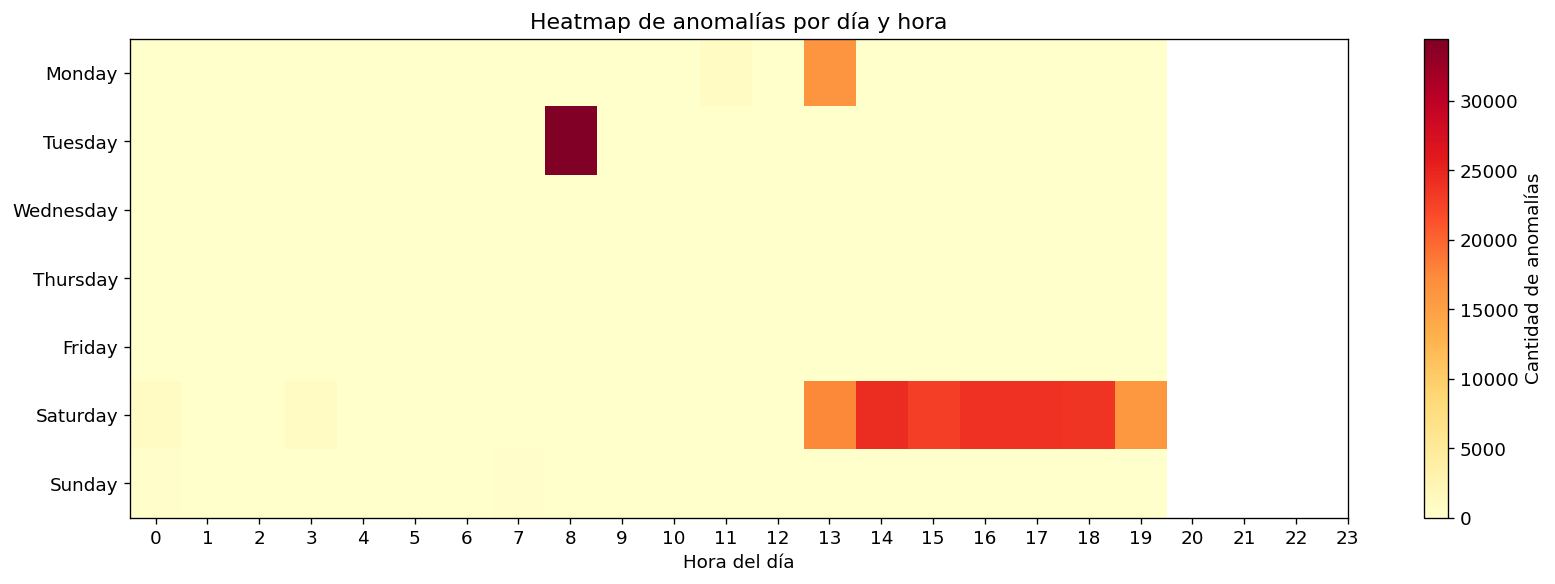

In [8]:
df_anom = df[df['is_anomaly']].copy()
df_anom['hour'] = df_anom['timestamp'].dt.hour
df_anom['weekday'] = df_anom['timestamp'].dt.day_name()

days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
heatmap = df_anom.groupby(['weekday', 'hour']).size().unstack(fill_value=0)
heatmap = heatmap.reindex([d for d in days_order if d in heatmap.index])

fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(heatmap.values, aspect='auto', cmap='YlOrRd')
ax.set_xticks(range(24))
ax.set_xticklabels(range(24))
ax.set_yticks(range(len(heatmap.index)))
ax.set_yticklabels(heatmap.index)
ax.set_xlabel('Hora del día')
ax.set_title('Heatmap de anomalías por día y hora')
plt.colorbar(im, ax=ax, label='Cantidad de anomalías')
plt.tight_layout()
plt.savefig('../reports/figures/01_heatmap_anomalies.png', dpi=150)
plt.show()

## 7. Distribución de anomalías por tipo (label)

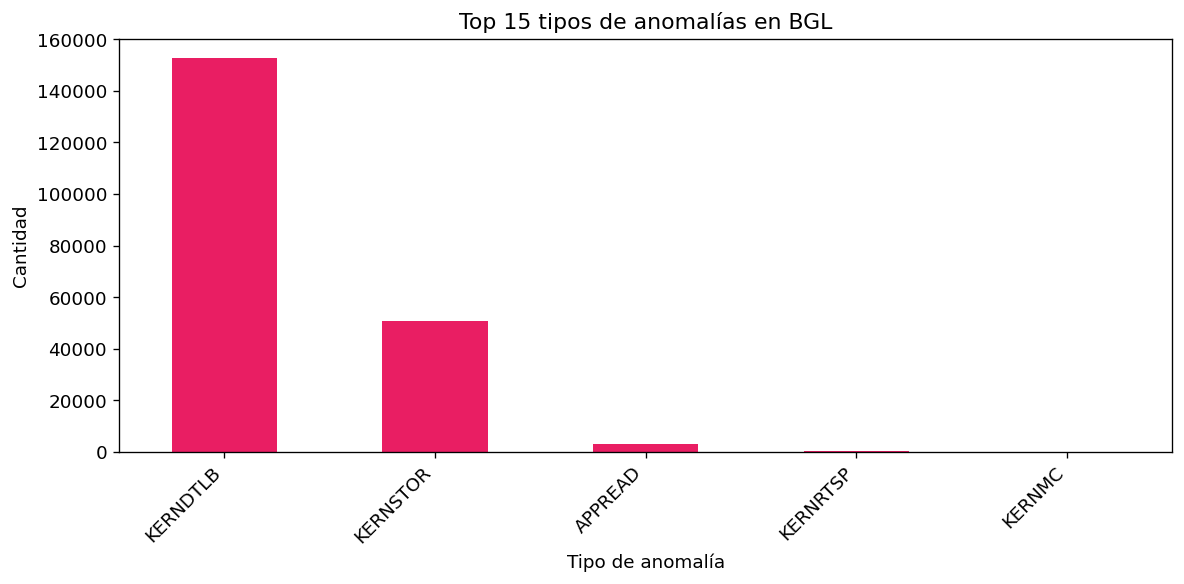

label
KERNDTLB    152659
KERNSTOR     50864
APPREAD       3181
KERNRTSP       133
KERNMC          10
Name: count, dtype: int64


In [9]:
anomaly_types = df[df['is_anomaly']]['label'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 5))
anomaly_types.plot(kind='bar', ax=ax, color='#E91E63')
ax.set_xlabel('Tipo de anomalía')
ax.set_ylabel('Cantidad')
ax.set_title('Top 15 tipos de anomalías en BGL')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../reports/figures/01_anomaly_types.png', dpi=150)
plt.show()

print(anomaly_types)

## 8. Conclusiones del EDA

**Class imbalance:** ~7-8% de anomalías (ligeramente más alto que el rango esperado 2-5%). Esto refuerza la necesidad de métricas orientadas a precision/recall, no accuracy.

**Patrones temporales:** Las anomalías se agrupan en clusters temporales, no están distribuidas uniformemente. Esto valida el uso de ventanas temporales como features.

**Distribución por nodo:** Ciertos nodos concentran muchas más anomalías — `node_error_ratio` será una feature discriminativa.

**Niveles dominantes:** INFO domina, pero las anomalías coinciden con FATAL/ERROR — `severity_score` es relevante.

**Estrategia de features (Fase 2):**
- Ventanas temporales 1/5/15 min con conteos de ERROR/FATAL
- Tasas de error y burst flags
- Estadísticas por nodo (error_ratio, avg_severity)
- Encoding de frecuencia para componentes top-20